In [1]:
import torch
import torch.nn as nn

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 256, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "dropout_layer": 0.1,       # Dropout rate
    "qkv_bias": False      # Query-Key-Value bias
}

In [3]:
import torch
import torch.nn as nn
import math

class Multi_Head_Attention(nn.Module):
    def __init__(self, din_, dout, dropout_r, numh, context_length, bias=False):
        super().__init__()
        assert dout % numh == 0, "dout must be divisible by numh"
        self.dout = dout
        self.heads = numh
        self.head_dim = dout // numh
        self.w_query = nn.Linear(din_, dout, bias=bias)
        self.w_key = nn.Linear(din_, dout, bias=bias)
        self.w_value = nn.Linear(din_, dout, bias=bias)
        self.out_proj = nn.Linear(dout, dout, bias=bias)
        self.dropout = nn.Dropout(dropout_r)
        # mask ek baar banao
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1).bool()
        )

    def forward(self, x):
        batch, num_tokens, din_emb = x.shape
        query = self.w_query(x)
        key = self.w_key(x)
        value = self.w_value(x)

        query = query.view(batch, num_tokens, self.heads, self.head_dim).transpose(1, 2)
        key = key.view(batch, num_tokens, self.heads, self.head_dim).transpose(1, 2)
        value = value.view(batch, num_tokens, self.heads, self.head_dim).transpose(1, 2)

        attn_scores = query @ key.transpose(2, 3)
        # sqrt fix
        attn_scores = attn_scores.masked_fill(
            self.mask[:num_tokens, :num_tokens], -torch.inf
        )
        attn_weights = torch.softmax(attn_scores / math.sqrt(self.head_dim), dim=-1)
        attn_weights = self.dropout(attn_weights)

        context = (attn_weights @ value).transpose(1, 2)
        context = context.contiguous().view(batch, num_tokens, self.dout)
        return self.out_proj(context)


class Layer_Normalization(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        variance = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.scale * (x - mean) / torch.sqrt(variance + self.eps) + self.shift


class Gelu(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            math.sqrt(2 / math.pi) * (x + 0.44715 * x.pow(3))
        ))


class Feed_Forward_block(nn.Module):
    def __init__(self, no_emb):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(no_emb, 4 * no_emb, bias=True),
            Gelu(),
            nn.Linear(4 * no_emb, no_emb, bias=True)
        )

    def forward(self, x):
        return self.model(x)


class Transformer_Block(nn.Module):
    def __init__(self, Gpt_arch):
        super().__init__()
        self.attention = Multi_Head_Attention(
            din_=Gpt_arch['emb_dim'],
            dout=Gpt_arch['emb_dim'],
            numh=Gpt_arch['n_heads'],
            dropout_r=Gpt_arch['dropout_layer'],
            context_length=Gpt_arch['context_length'],
            bias=Gpt_arch['qkv_bias']
        )
        self.ff = Feed_Forward_block(Gpt_arch['emb_dim'])
        self.norm1 = Layer_Normalization(Gpt_arch['emb_dim'])
        self.norm2 = Layer_Normalization(Gpt_arch['emb_dim'])
        self.dropout = nn.Dropout(Gpt_arch['dropout_layer'])

    def forward(self, x):
        # Attention block — shortcut fix
        x = x + self.dropout(self.attention(self.norm1(x)))
        # FFN block — shortcut fix
        x = x + self.dropout(self.ff(self.norm2(x)))
        return x


class Quasar(nn.Module):
    def __init__(self, Gpt_arch):
        super().__init__()
        self.tok_emb = nn.Embedding(Gpt_arch['vocab_size'], Gpt_arch['emb_dim'])
        self.pos_emb = nn.Embedding(Gpt_arch['context_length'], Gpt_arch['emb_dim'])
        self.drop_emb = nn.Dropout(Gpt_arch['dropout_layer'])
        self.transformer_blocks = nn.Sequential(
            *[Transformer_Block(Gpt_arch) for _ in range(Gpt_arch['n_layers'])]
        )
        self.norm = Layer_Normalization(Gpt_arch['emb_dim'])
        self.out_head = nn.Linear(Gpt_arch['emb_dim'], Gpt_arch['vocab_size'], bias=False)

    def forward(self, x):
        batch, seq_len = x.shape
        tok = self.tok_emb(x)
        pos = self.pos_emb(torch.arange(seq_len, device=x.device))
        x = self.drop_emb(tok + pos)
        x = self.transformer_blocks(x)
        x = self.norm(x)
        return self.out_head(x)

## All configuration of the Thins things happen above


---


*   Multi_Head_Attention: This block is to generate query key and value weights of n_heads which can be used to attain the attention on the each block of the data
* Layer_Normalization: Reduce vanishing and exploading gradient problem
* Gelu ,feed forward used to generate the transformer block
* Transformer : consist of all above block which need to generate the next word it gives the logits
* Quasar which will integrate and generate the logits to predict next word




In [4]:
with open('/content/the-verdict.txt','r') as f:
  text_data=f.read()

In [5]:
import tiktoken
tokenizer=tiktoken.get_encoding('gpt2')

In [6]:
from torch.utils.data import Dataset,DataLoader
class GptDatasetv1(Dataset):
    def __init__(self,data,tokenizer,max_lenght,stride):
        super().__init__()
        self.input=[]
        self.target=[]
        token_ids=tokenizer.encode(data,allowed_special={"<|endoftext|>"})
        for i in range(0,len(token_ids)-max_lenght,stride):
            input_chunk=token_ids[i:i+max_lenght]
            target_chunk=token_ids[i+1:i+max_lenght+1]
            self.input.append(torch.tensor(input_chunk))
            self.target.append(torch.tensor(target_chunk))
    def __len__(self):
        return len(self.input)
    def __getitem__(self, index):
        return self.input[index],self.target[index]
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GptDatasetv1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

In [7]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [93]:
def batch_loss_calucater(data_loader,model,device,numbatches=None):
    total_loss=0.0
    if len(data_loader) == 0:
        return float("nan")
    elif numbatches is None:
        numbatches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        numbatches = min(numbatches, len(data_loader))
    for i ,(input,target) in enumerate(data_loader):
        if i<numbatches:
            loss=Loss_batch_calc(input,target,model,device) # Changed from call_loss_batch
            total_loss+=loss.item()
        else: break
    return total_loss/numbatches

## The above block is to calculate the loss and do backward propagation

In [94]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [95]:
quasar=Quasar(GPT_CONFIG_124M)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
quasar.to(device)

Quasar(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): Transformer_Block(
      (attention): Multi_Head_Attention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_key): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): Feed_Forward_block(
        (model): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): Gelu()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): Layer_Normalization()
      (norm2): Layer_Normalization()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): Transformer_Block(
      (attention): Multi_Head_At

In [11]:
def generate_text(input,tokenizer):
    text=input
    text_ip=tokenizer.encode(text)
    text_ip=torch.tensor(text_ip).unsqueeze(0)
    return text_ip
def decode_text(inputs_idx,tokenizer):
    generated_text=tokenizer.decode(inputs_idx.squeeze(0).tolist())
    return generated_text


In [12]:
def generate_text_simple(model,input,max_tokens,context_size):
    generated_text=input
    for _ in range(max_tokens):
        idn=generated_text[:,-context_size:]
        # get prediction
        with torch.no_grad():
            logits=model(idn)
        logits=logits[:,-1,:]
        probas=torch.softmax(logits,dim=-1)
        next_word=torch.argmax(probas,dim=-1,keepdim=True)
        generated_text=torch.cat((generated_text,next_word),dim=1)
    return generated_text

In [13]:
def evaluate_model(train_set,validation_set,model,device,eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss=batch_loss_calucater(train_set,quasar,device,numbatches=eval_iter)
        val_loss=batch_loss_calucater(validation_set,quasar,device,numbatches=eval_iter)
    model.train()
    return train_loss,val_loss

In [14]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = generate_text(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, input=encoded,
            max_tokens=50, context_size=context_size
        )
    decoded_text =decode_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [15]:
def model_training(model,train_loader,val_loader,device,epochs,eval_freq,start_context,optimizer,eval_iter,tokenizer):
    train_losses,val_losses,track_tokens_seen=[],[],[]
    token_seen,global_step=0,-1
    for epoch in range(epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss=call_loss_batch(input_batch,target_batch,model,device)
            loss.backward()
            optimizer.step()
            token_seen+=input_batch.numel()
            global_step+=1
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model=model,train_set=train_loader,validation_set=val_loader,device=device,eval_iter=eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(token_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
        generate_and_print_sample(model,tokenizer,device,start_context)
    return train_losses,val_losses,track_tokens_seen

# Model training block to train model

In [16]:
optimizer=torch.optim.AdamW(quasar.parameters(),lr=0.0004,weight_decay=0.1)

In [17]:
train_losses,val_losses,track_tokens=model_training(model=quasar,train_loader=train_loader,val_loader=val_loader,device=device,epochs=10,eval_freq=5,eval_iter=5,start_context="hello",optimizer=optimizer,tokenizer=tokenizer)

Ep 1 (Step 000000): Train loss 9.859, Val loss 9.995
Ep 1 (Step 000005): Train loss 8.132, Val loss 8.269
hello,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Step 000010): Train loss 6.723, Val loss 7.034
Ep 2 (Step 000015): Train loss 6.060, Val loss 6.558
hello, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and
Ep 3 (Step 000020): Train loss 5.666, Val loss 6.532
Ep 3 (Step 000025): Train loss 5.491, Val loss 6.458
hello, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and the, and the, and the, and the, and the, and the, and
Ep 4 (Step 000030): Train loss 5.050, Val loss 6.344
Ep 4 (Step 000035): Train loss 4.028, Val loss 6.267
hello, the end of the " of the fact of the fact--and a little the fact of the fact--and, and in the          "I. I had been. I had been the end of
Ep 5 (Step 000040): Train loss 3.482, Val loss 6.159
hello, for you know. "Yes--I.     "I turned back 

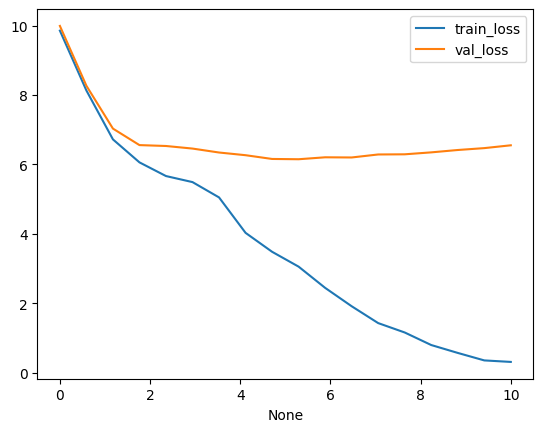

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(y=train_losses,x=torch.linspace(0,10, steps=len(train_losses)),label="train_loss")
sns.lineplot(y=val_losses,x=torch.linspace(0,10, steps=len(val_losses)),label="val_loss")
plt.show()

In [19]:
def generate_text_input(model,context_length,max_tokens,context_size,tokenizer):
  encoded_input = generate_text(context_length, tok).to(device)
  output_token_ids = generate_text_simple(model=quasar, input=encoded_input, max_tokens=50, context_size=256)
  output = decode_text(output_token_ids, tok)
  return output

In [20]:
tok=tiktoken.get_encoding('gpt2')
inputs="hy this is "
quasar.eval()
# Correcting the input for generate_text_simple by tokenizing directly
generated_text = generate_text_input(quasar, inputs, 50, 256, tok)
print(generated_text)

hy this is ?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"

He laughed again, and threw back his head to look up at the sketch of the donkey. "strongest," as his


In [21]:
def generate_logits(model,input,context_size):
    # Use the 'input' parameter instead of the global 'generated_text'
    idn=input[:,-context_size:]
    # get prediction
    with torch.no_grad():
        logits=model(idn)
    logits=logits[:,-1,:]
    return logits

In [22]:
def generate_text_input(model,context,max_tokens,context_size,tokenizer,temperature=0.7,top_k=40,eposid=None):
  encoded_input = generate_text(context, tokenizer).to(device)
  for _ in range(max_tokens):
    idn=encoded_input[:,-context_size:]
    logits=generate_logits(model,idn,context_size)

    # Apply top_k filtering
    if top_k is not None:
      # Get the top_k values and indices
      top_k_values, top_k_indices = torch.topk(logits, k=top_k)
      # Create a mask for logits outside the top_k
      min_val_in_topk = top_k_values[:, -1].unsqueeze(-1)
      logits = torch.where(logits < min_val_in_topk, torch.tensor(-float('inf'), device=logits.device), logits)

    # Apply temperature scaling
    if temperature > 0.0:
      logits = logits / temperature

    probas = torch.softmax(logits, dim=-1)

    # Debugging: Print top 5 predicted tokens and probabilitie

    # Sample the next word
    next_word = torch.multinomial(probas, num_samples=1)

    if eposid is not None and next_word==eposid:
      break
    encoded_input=torch.cat((encoded_input,next_word),dim=1)
  output = decode_text(encoded_input,tokenizer)
  return output

In [23]:
context="Give me"
generate_text_input(model=quasar,context=context,max_tokens=50,context_size=256,tokenizer=tok,temperature=9,top_k=25)

'Give me he lay,agged not onlyburn appeared down the Riv--so": back fellow-res not own--she by surprise went simple again"? to see like degree threw then\'s saidly, married a and were him _mine ease anin him at'

In [24]:
# # How to resume the weights and optimizer state
# torch.save({
#     'Model_weights':quasar.state_dict(),
#     'optimizer':optimizer.state_dict()
# },"model_optim.pth")

In [25]:
# # Loading_weights and model_weights
# checkpoint=torch.load("model_optim.pth")
# quasar.load_state_dict(checkpoint['Model_weights'])
# optimizer.load_state_dict(checkpoint['optimizer'])

In [26]:
# Using openai weights for GPT_2
import tensorflow as tf
import tqdm


In [27]:
from gpt_download3 import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 279kiB/s]
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.81MiB/s]
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verificat

In [28]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [29]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

In [30]:
NEW_CONFIG

{'vocab_size': 50257,
 'context_length': 256,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'dropout_layer': 0.1,
 'qkv_bias': False}

In [31]:
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})
gpt = Quasar(NEW_CONFIG)
gpt.eval();

In [32]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.transformer_blocks[b].attention.w_query.weight = assign(
            gpt.transformer_blocks[b].attention.w_query.weight, q_w.T)
        gpt.transformer_blocks[b].attention.w_key.weight = assign(
            gpt.transformer_blocks[b].attention.w_key.weight, k_w.T)
        gpt.transformer_blocks[b].attention.w_value.weight = assign(
            gpt.transformer_blocks[b].attention.w_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.transformer_blocks[b].attention.w_query.bias = assign(
            gpt.transformer_blocks[b].attention.w_query.bias, q_b)
        gpt.transformer_blocks[b].attention.w_key.bias = assign(
            gpt.transformer_blocks[b].attention.w_key.bias, k_b)
        gpt.transformer_blocks[b].attention.w_value.bias = assign(
            gpt.transformer_blocks[b].attention.w_value.bias, v_b)

        gpt.transformer_blocks[b].attention.out_proj.weight = assign(
            gpt.transformer_blocks[b].attention.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.transformer_blocks[b].attention.out_proj.bias = assign(
            gpt.transformer_blocks[b].attention.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.transformer_blocks[b].ff.model[0].weight = assign(
            gpt.transformer_blocks[b].ff.model[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.transformer_blocks[b].ff.model[0].bias = assign(
            gpt.transformer_blocks[b].ff.model[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.transformer_blocks[b].ff.model[2].weight = assign(
            gpt.transformer_blocks[b].ff.model[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.transformer_blocks[b].ff.model[2].bias = assign(
            gpt.transformer_blocks[b].ff.model[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.transformer_blocks[b].norm1.scale = assign(
            gpt.transformer_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.transformer_blocks[b].norm1.shift = assign(
            gpt.transformer_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.transformer_blocks[b].norm2.scale = assign(
            gpt.transformer_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.transformer_blocks[b].norm2.shift = assign(
            gpt.transformer_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.norm.scale = assign(gpt.norm.scale, params["g"])
    gpt.norm.shift = assign(gpt.norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

# Loading  Weights from openai gpt-2 weights

In [33]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [34]:
load_weights_into_gpt(gpt, params)
gpt.to(device);

In [35]:
context="hello thhis is soldier boy"
generate_text_input(model=gpt,context=context,max_tokens=50,context_size=256,tokenizer=tok,temperature=1.9,top_k=25)

'hello thhis is soldier boyish on his last act\n\n\nSaving up his chance of helping him, I asked them to look after his daughter as to where and she replied "if he got in that way of doing his best friends and I can barely make a second of'

In [36]:
import kagglehub
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
path

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.


'/kaggle/input/sms-spam-collection-dataset'

In [37]:
import pandas as pd
df=pd.read_csv(path+"/spam.csv",encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [38]:
df=df[['v1','v2']]

In [39]:
df['v1'].value_counts()

,count
v1,
ham,4825
spam,747


In [40]:
df_hamed=df[df['v1']=='ham'].sample(747)
df_spam=df[df['v1']=='spam']

In [41]:
balanced_df=pd.concat([df_hamed,df_spam])
balanced_df['v1']=balanced_df['v1'].map({'ham':0,'spam':1})

In [42]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

In [43]:
train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

In [44]:
train_df.shape,validation_df.shape,test_df.shape

((1045, 2), (149, 2), (300, 2))

In [45]:
class SpamDataset(Dataset):
    def __init__(self, Data, tokenizer, max_length=None, pad_token_id=50256):
        self.data = Data

        # Pre-tokenize texts - changed from 'Text' to 'v2'
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["v2"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate sequences if they are longer than max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Pad sequences to the longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        # Changed from 'Label' to 'v1'
        label = self.data.iloc[index]["v1"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

In [46]:
train_dataset=SpamDataset(train_df,tokenizer,max_length=None)
val_dataset=SpamDataset(validation_df,tokenizer,max_length=train_dataset.max_length)

In [47]:
test_dataset=SpamDataset(test_df,tokenizer,max_length=train_dataset.max_length)

In [48]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [49]:
GPT_CONFIG_124M['context_length']=1024

In [50]:
modelx_config = GPT_CONFIG_124M.copy()
modelx_config['qkv_bias'] = True
Modelx=Quasar(modelx_config)
load_weights_into_gpt(Modelx,params)
Modelx.to(device)
Modelx.eval();

In [51]:
generate_text_input(Modelx,context="Every effort moves you",max_tokens=70,context_size=modelx_config['context_length'],tokenizer=tokenizer,temperature=1.5
                    )

"Every effort moves you as usual the campaign to raise awareness of the matter. It's certainly possible that more people than your own political party wouldn't buy the bill by Hillary voters on Tuesday — there's an awful little twist to that outcome, as it has every bit the wrong people think the real and just plain incorrect that's been so long it over-entitifies"

In [52]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
generate_text_input(Modelx,context=text_2,max_tokens=15,context_size=modelx_config['context_length'],tokenizer=tokenizer,temperature=1.5
                    )

"Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.' It's easy for me and I do a poor, healthy life that much"

In [53]:
for parameters in Modelx.parameters():
  parameters.requires_grad=False

In [59]:
torch.manual_seed(344)
num_class=2
Modelx.out_head=nn.Linear(NEW_CONFIG['emb_dim'],num_class)
Modelx.to(device)

Quasar(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): Transformer_Block(
      (attention): Multi_Head_Attention(
        (w_query): Linear(in_features=768, out_features=768, bias=True)
        (w_key): Linear(in_features=768, out_features=768, bias=True)
        (w_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): Feed_Forward_block(
        (model): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): Gelu()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): Layer_Normalization()
      (norm2): Layer_Normalization()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): Transformer_Block(
      (attention): Multi_Head_Attent

In [56]:
for param in Modelx.transformer_blocks[-1].parameters():
    param.requires_grad = True

for param in Modelx.norm.parameters():
    param.requires_grad = True

In [110]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, Modelx.parameters()),
    lr=0.0004,
    weight_decay=0.1
)

In [111]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0).to(device)
with torch.no_grad():
  logits=Modelx(inputs)
print(logits)

tensor([[[-0.1349, -1.4895],
         [-1.8227, -7.5623],
         [-1.9879, -5.8793],
         [-2.5030, -5.6923]]], device='cuda:0')


In [112]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

In [113]:
def Loss_batch_calc(input_batch,target_batch, model,device):
  input_batch,target_batch=input_batch.to(device),target_batch.to(device)
  logits=model(input_batch)[:,-1,:]
  loss=torch.nn.functional.cross_entropy(logits,target_batch)
  return loss

In [114]:
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = Loss_batch_calc(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            examples_seen += input_batch.shape[0] # New: track examples instead of tokens
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [115]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = batch_loss_calucater(train_loader, model, device, numbatches=eval_iter)
        val_loss = batch_loss_calucater(val_loader, model, device, numbatches=eval_iter)
    model.train()
    return train_loss, val_loss

In [116]:
optimizer

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0004
    maximize: False
    weight_decay: 0.1
)

In [117]:
train_losses,val_losses,train_accs,val_accs,examples_seen=train_classifier_simple(Modelx,train_loader,val_loader,optimizer,device,num_epochs=10,eval_freq=50,eval_iter=len(val_loader))

Ep 1 (Step 000000): Train loss 0.729, Val loss 0.711
Ep 1 (Step 000050): Train loss 0.498, Val loss 0.456
Ep 1 (Step 000100): Train loss 0.240, Val loss 0.232
Training accuracy: 92.76% | Validation accuracy: 95.97%
Ep 2 (Step 000150): Train loss 0.045, Val loss 0.109
Ep 2 (Step 000200): Train loss 0.130, Val loss 0.104
Ep 2 (Step 000250): Train loss 0.119, Val loss 0.165
Training accuracy: 98.68% | Validation accuracy: 98.66%
Ep 3 (Step 000300): Train loss 0.052, Val loss 0.064
Ep 3 (Step 000350): Train loss 0.024, Val loss 0.048
Training accuracy: 99.34% | Validation accuracy: 99.33%
Ep 4 (Step 000400): Train loss 0.132, Val loss 0.122
Ep 4 (Step 000450): Train loss 0.036, Val loss 0.046
Ep 4 (Step 000500): Train loss 0.124, Val loss 0.078
Training accuracy: 100.00% | Validation accuracy: 98.66%
Ep 5 (Step 000550): Train loss 0.012, Val loss 0.043
Ep 5 (Step 000600): Train loss 0.057, Val loss 0.050
Training accuracy: 95.39% | Validation accuracy: 97.32%
Ep 6 (Step 000650): Train loss

In [118]:
torch.save({
    "model_state_dict":Modelx.state_dict(),

},"spam_ham.pth")

In [119]:
from google.colab import files
files.download('spam_ham.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

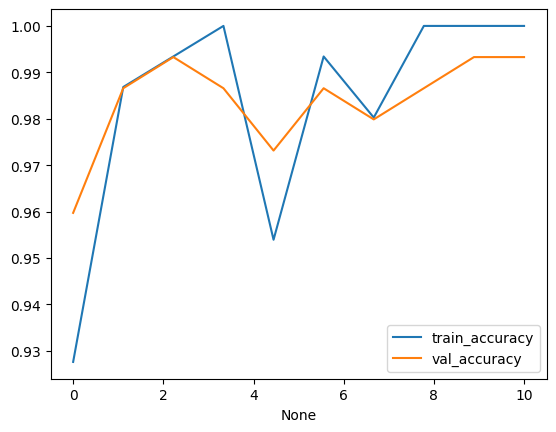

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(y=train_accs, x=torch.linspace(0, 10, steps=len(train_accs)), label="train_accuracy")
sns.lineplot(y=val_accs, x=torch.linspace(0, 10, steps=len(val_accs)), label="val_accuracy")
plt.show()

In [121]:
train_accuracy = calc_accuracy_loader(train_loader, Modelx, device)
val_accuracy = calc_accuracy_loader(val_loader, Modelx, device)
test_accuracy = calc_accuracy_loader(test_loader, Modelx, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 99.62%
Validation accuracy: 99.33%
Test accuracy: 96.33%


In [137]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    # Note: In the book, this was originally written as pos_emb.weight.shape[1] by mistake
    # It didn't break the code but would have caused unnecessary truncation (to 768 instead of 1024)

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]

    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    return "spam" if predicted_label == 1 else "not spam"

In [138]:
train_dataset.max_length

257

In [139]:
text="You won $20000 from lottery"
classify_review(text=text,model=Modelx,tokenizer=tokenizer,device=device,max_length=train_dataset.max_length)

'spam'

In [140]:
new_model=Quasar(NEW_CONFIG)
# Re-initialize the output head to match the saved model's output head for classification
# 'num_class' was defined as 2 for spam/ham classification
new_model.out_head = nn.Linear(NEW_CONFIG['emb_dim'], 2)
new_model.to(device)

Quasar(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): Transformer_Block(
      (attention): Multi_Head_Attention(
        (w_query): Linear(in_features=768, out_features=768, bias=True)
        (w_key): Linear(in_features=768, out_features=768, bias=True)
        (w_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): Feed_Forward_block(
        (model): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): Gelu()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): Layer_Normalization()
      (norm2): Layer_Normalization()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): Transformer_Block(
      (attention): Multi_Head_Attent

In [141]:
checkpoint = torch.load('/content/spam_ham.pth')
new_model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [142]:
classify_review(text=text,model=new_model,tokenizer=tokenizer,device=device,max_length=train_dataset.max_length)

'spam'